In [ ]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from omegaconf import OmegaConf

os.environ["MUJOCO_GL"] = "egl"

repo_root = Path("/home/helix/projects/METRA-Projects/FlashSAC")
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from flash_rl.agents.metra.agent import METRAAgent
from flash_rl.agents.metra.sampler import Sampler
from flash_rl.envs.envs.mujoco.ant_env import AntEnv

def _latest_checkpoint_path(root: Path) -> Path:
    run_dirs = sorted([path for path in root.glob("seed*") if path.is_dir()])
    if not run_dirs:
        raise FileNotFoundError(f"No run directories found under {root}")

    latest_run = run_dirs[-1]
    checkpoint_paths = sorted(
        latest_run.glob("epoch*/agent_state.pt"),
        key=lambda path: int(path.parent.name.replace("epoch", "")),
    )
    if not checkpoint_paths:
        raise FileNotFoundError(f"No checkpoints found under {latest_run}")
    return checkpoint_paths[-1]

checkpoint_root = repo_root / "models" / "general" / "general_train"
checkpoint_override = checkpoint_root / "seed511527-0529-145128" / "epoch5000" / "agent_state.pt"
checkpoint_path = checkpoint_override if checkpoint_override.exists() else _latest_checkpoint_path(checkpoint_root)
resolved_cfg_path = checkpoint_path.parent.parent / "resolved_config.yaml"
cfg = OmegaConf.load(resolved_cfg_path)
agent_cfg = cfg.agent
print(f"Using checkpoint: {checkpoint_path}")
print(f"Using resolved config: {resolved_cfg_path}")
print(OmegaConf.to_yaml(cfg))

Using checkpoint: /home/helix/projects/METRA-Projects/FlashSAC/models/general/general_train/seed511527-0529-191504/epoch2800/agent_state.pt
Using resolved config: /home/helix/projects/METRA-Projects/FlashSAC/models/general/general_train/seed511527-0529-191504/resolved_config.yaml
agent:
  skill_dim: 2
  model_master_dim: 1024
  model_master_num_layers: 2
  spectral_normalization: false
  dual_lam: 30
  alpha: 0.01
  common_lr: 0.0001
  gamma: 0.99
  buffer_max_length: 300000
  buffer_min_length: 10000
  sample_batch_size: 256
  target_coef: 1.0
  dual_slack: 0.001
  discount: 0.99
  tau: 0.005
project_name: Metra
group_name: general
exp_name: general_train
seed: 511527
logger_type: tensorboard
save_path: models/general/general_train/seed511527-TIMESTAMP
logging_per_epoch: 1
save_checkpoint_per_epoch: 100
save_final_checkpoint: true
max_checkpoints_to_keep: 1
epochs: 5000
updates_per_epoch: 50
paths_per_epoch: 8
env_pos_info: true
obs_norm: false
config_name: general_base
entity_name: l

In [2]:
env = AntEnv(render_hw=100, obs_norm=cfg.obs_norm)
agent = METRAAgent(env, agent_cfg)

checkpoint = torch.load(checkpoint_path, map_location=agent.device)
agent.option_policy.load_state_dict(checkpoint["option_policy_state_dict"])
agent.qf1.load_state_dict(checkpoint["qf1_state_dict"])
agent.qf2.load_state_dict(checkpoint["qf2_state_dict"])
agent.target_qf1.load_state_dict(checkpoint["target_qf1_state_dict"])
agent.target_qf2.load_state_dict(checkpoint["target_qf2_state_dict"])
agent.skill_encoder.load_state_dict(checkpoint["skill_encoder_state_dict"])
agent.dual_lam.load_state_dict(checkpoint["dual_lam_state_dict"])
agent.log_alpha.load_state_dict(checkpoint["log_alpha_state_dict"])

agent.option_policy.eval()
agent.qf1.eval()
agent.qf2.eval()
agent.target_qf1.eval()
agent.target_qf2.eval()
agent.skill_encoder.eval()

sampler = Sampler(env=env, skill_dim=agent_cfg.skill_dim)
print(f"Loaded epoch: {checkpoint['epoch']}")
print(f"Loaded update step: {checkpoint['global_update_step']}")
print(f"obs_norm: {cfg.obs_norm}")

Loaded epoch: 2800
Loaded update step: 140000
obs_norm: False


In [3]:
def rollout_paths(policy, sampler, num_paths=8, path_len=200):
    paths = []
    for _ in range(num_paths):
        path = sampler.rollout(policy, path_len=path_len, training=False)
        coords = path["observation"].detach().cpu().numpy()[:, :2]
        skill = path["skill"][0].detach().cpu().numpy()
        paths.append({
            "coords": coords,
            "skill": skill,
        })
    return paths

def plot_xy_rollouts(paths):
    plt.figure(figsize=(8, 8))
    cmap = plt.cm.get_cmap("tab10", len(paths))

    for idx, path in enumerate(paths):
        coords = path["coords"]
        skill = path["skill"]
        color = cmap(idx)

        plt.plot(coords[:, 0], coords[:, 1], color=color, linewidth=1.8, label=f"rollout {idx + 1}")
        plt.scatter(coords[0, 0], coords[0, 1], color=color, s=35, marker="o")
        plt.scatter(coords[-1, 0], coords[-1, 1], color=color, s=45, marker="x")

        displacement_scale = max(np.linalg.norm(coords[-1] - coords[0]), 0.2)
        skill_dir = skill / (np.linalg.norm(skill) + 1e-8)
        skill_arrow = skill_dir * displacement_scale * 0.35
        plt.arrow(
            coords[0, 0],
            coords[0, 1],
            skill_arrow[0],
            skill_arrow[1],
            color=color,
            width=0.002,
            head_width=0.04,
            length_includes_head=True,
            alpha=0.8,
        )

    plt.title("8 Random-Skill Rollout XY Trajectories")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2029291/3170055318.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(paths))


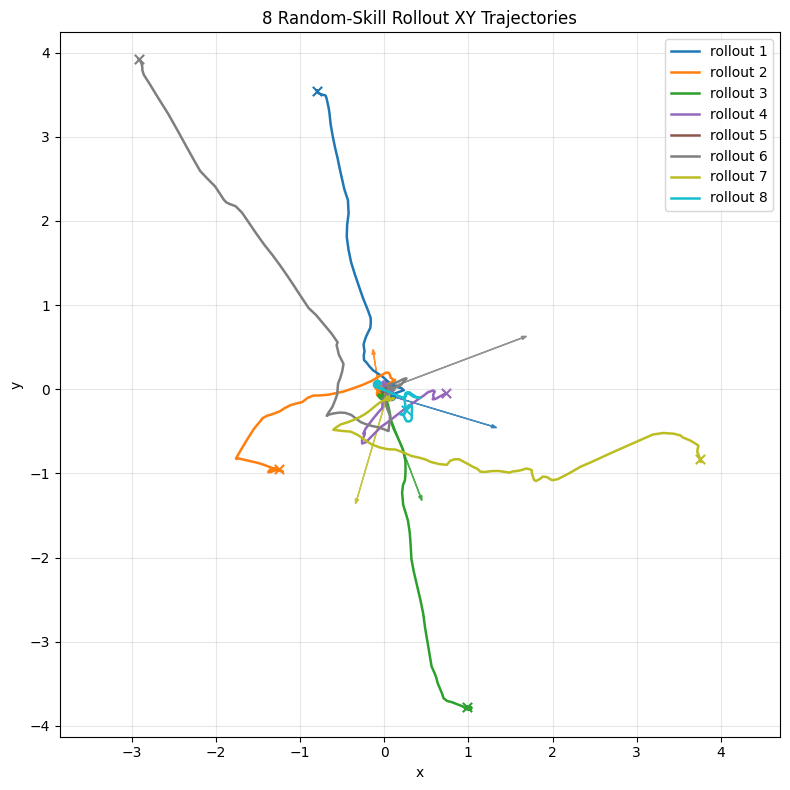

rollout 1: skill=[ 0.9576571  -0.28791115], displacement=[-0.8834531  3.627482 ]
rollout 2: skill=[-0.15180056  0.9884112 ], displacement=[-1.191776  -0.9078129]
rollout 3: skill=[ 0.35597372 -0.934496  ], displacement=[ 1.0133754 -3.7023578]
rollout 4: skill=[-0.0199149 -0.9998017], displacement=[ 0.7179432 -0.1089269]
rollout 5: skill=[-0.88305867  0.4692625 ], displacement=[-0.0466618   0.01741452]
rollout 6: skill=[0.9357427 0.3526834], displacement=[-2.9966407  3.897952 ]
rollout 7: skill=[-0.2808714  -0.95974547], displacement=[ 3.7194147  -0.74432105]
rollout 8: skill=[ 0.80969703 -0.5868481 ], displacement=[ 0.35266292 -0.30167952]


In [4]:
paths = rollout_paths(agent.option_policy, sampler, num_paths=8, path_len=200)
plot_xy_rollouts(paths)

for idx, path in enumerate(paths, start=1):
    displacement = path["coords"][-1] - path["coords"][0]
    print(f"rollout {idx}: skill={path['skill']}, displacement={displacement}")